In [1]:
install.packages('triangle')
install.packages('igraph')


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



## Tarefa 1


Attaching package: ‘igraph’


The following objects are masked from ‘package:stats’:

    decompose, spectrum


The following object is masked from ‘package:base’:

    union




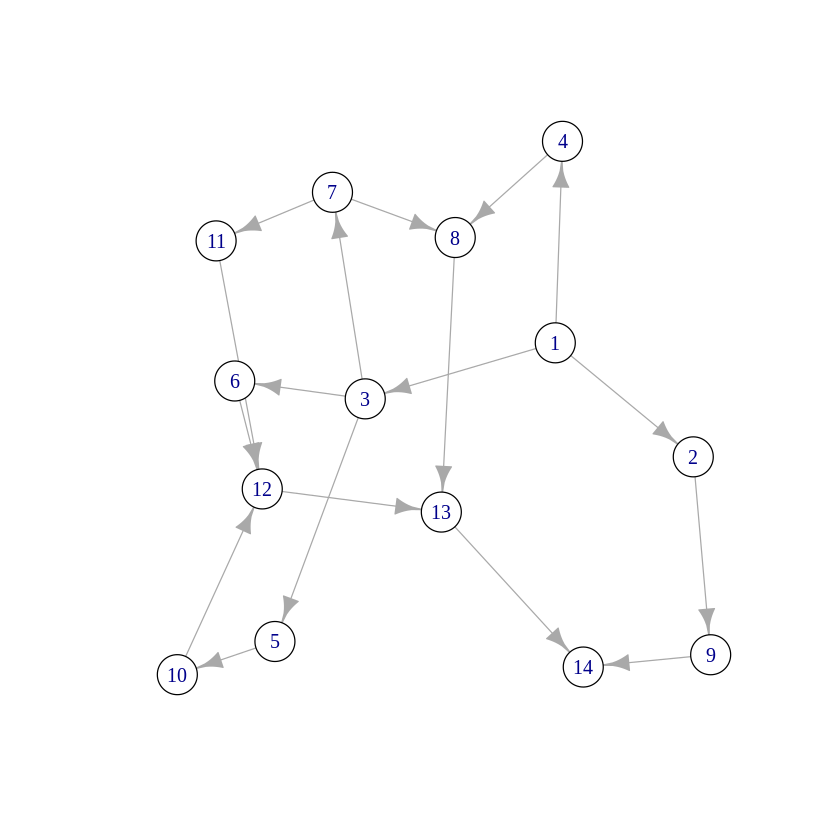

In [2]:
library(igraph)
library(triangle)

#1- Estruturas de dados globais
n  <- 14
Ns <- 10000

parDur <- matrix(data = c(
  0,   0.1, 0.2,
  4,   6,   10,
  2,   5,   8,
  2,   3,   6,
  0.5, 1,   2,
  3,   6,   10,
  1,   2,   4,
  0.5, 1,   3,
  2,   3,   6,
  2,   3,   5,
  1,   2,   3,
  1,   2,   4,
  3,   5,   8,
  0,   0.1, 0.2
), ncol = 3, byrow = TRUE)
# colunas: [Min, Mprov (moda), Max]

elos <- c(1,2, 1,3, 1,4, 2,9, 3,5, 3,6, 3,7,
          4,8, 5,10, 6,12, 7,11, 7,8, 8,13,
          9,14, 10,12, 11,12, 12,13, 13,14)

Suc <- list(c(2,3,4), 9, c(5,6,7), 8, 10, 12,
            c(8,11), 13, 14, 12, 12, 13, 14, 0)

Pre <- list(0, 1, 1, 1, 3, 3, 3, c(4,7), 2, 5,
            7, c(6,10,11), c(8,12), c(9,13))


durCC<-vector(mode='numeric',length=Ns)
g<-make_graph(elos)
plot(g,vertex.color='white')
sp<-all_simple_paths(g,from=1,to=14)
l<-length(sp)



[1] "Número de caminhos de 1 a 14: 6"


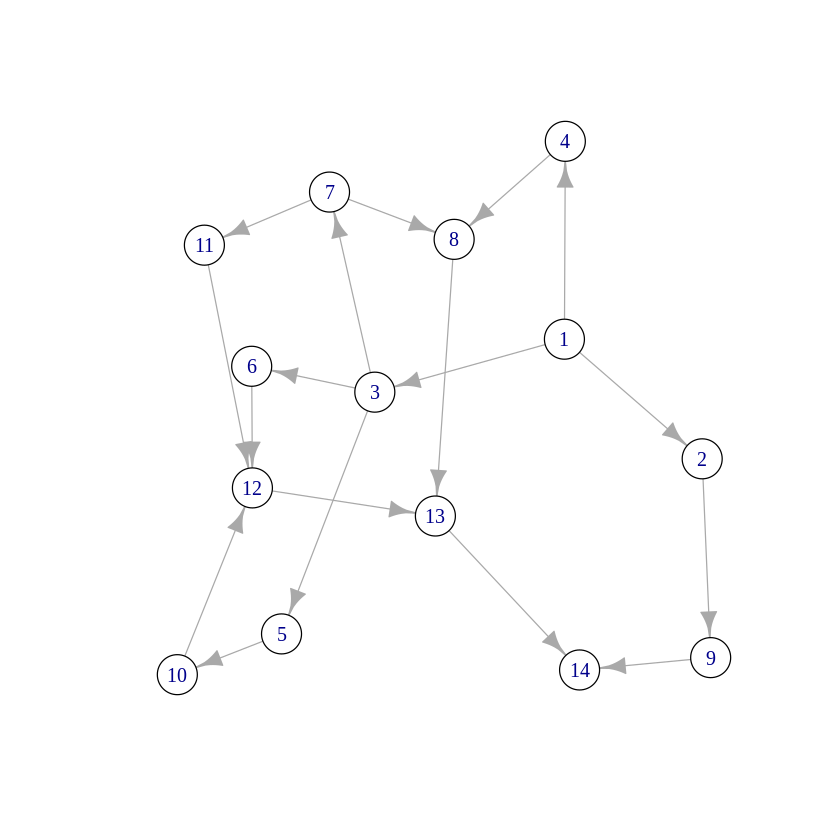

In [3]:
plot(g, vertex.color='white')
# Inspecione visualmente se as arestas batem com a figura
print(paste("Número de caminhos de 1 a 14:", l))

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  15.00   20.00   21.00   21.26   23.00   29.00 


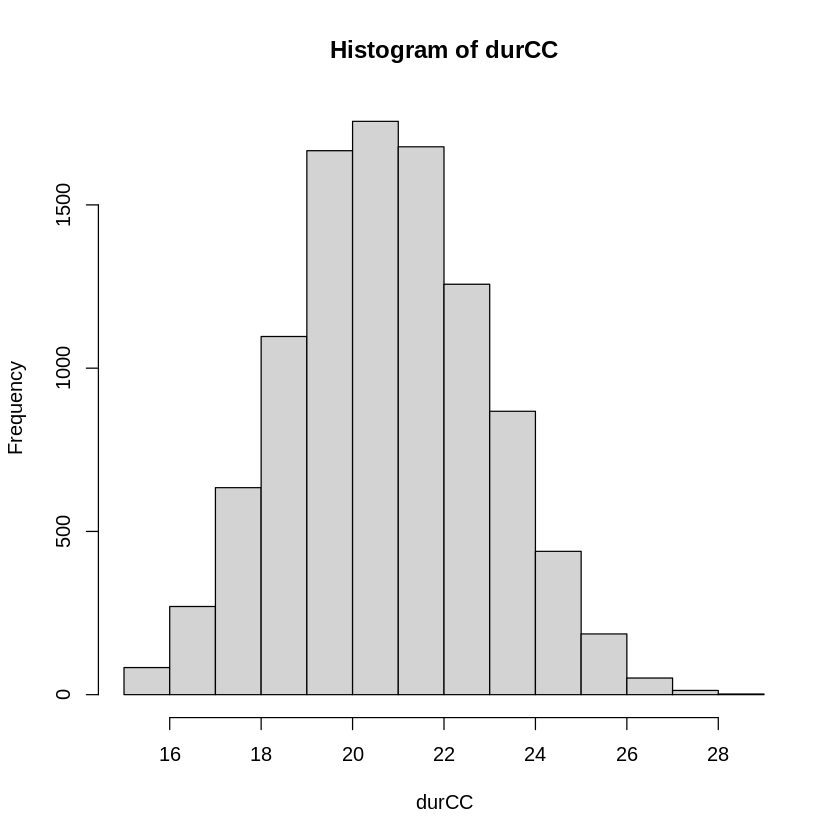

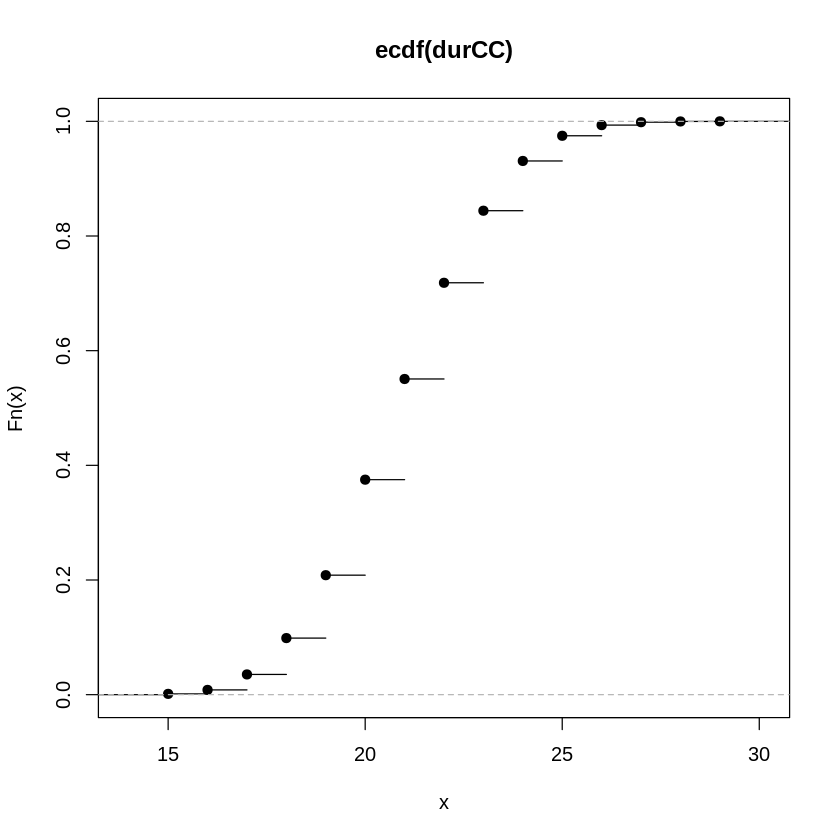

In [4]:
#2-cria amostras das duracoes dos caminhos
dur<-matrix(rep(0,Ns*n),nrow = Ns,ncol=n)
for(j in 1:Ns){
  for(i in 2:(n-1)){
    dur[j,i]<-ceiling(rtriangle(1,parDur[i,1],parDur[i,3],parDur[i,2]))
  }
}

# 3-para cada cenário calcule duracao CC
dc<-vector(mode="numeric",length=l)
for (i in 1:Ns){
  d<-dur[i,]
  for(j in 1:l){
    dc[j]<-sum(d[sp[[j]]])
  }
  icc<-which.max(dc)
  durCC[i] <-dc[icc]
}

# 4- Analise preliminar
print(summary(durCC))
hist(durCC)
plot(ecdf(durCC))

In [5]:
summary(durCC)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  15.00   20.00   21.00   21.26   23.00   29.00 

In [6]:
quantile(durCC, 0.85)

85% 
 24

In [7]:
funcCpm <- function(n=9,
                    d=c(0,2,6,4,3,5,4,2,0),
                    Suc=list(c(2,3,4),c(5,7),8,6,8,8,9,9,0),
                    Pre=list(0,1,1,1,2,4,2,c(3,5,6),c(7,8)))
{
  est <- rep(0, n)
  eft <- rep(0, n)
  lst <- rep(0, n)
  lft <- rep(0, n)

  # ---------- FORWARD ----------
  for(i in 1:n){
    if(Pre[[i]][1] != 0){
      est[i] <- max(eft[Pre[[i]]])
    }
    eft[i] <- est[i] + d[i]
  }

  # ---------- BACKWARD ----------
  lft[n] <- eft[n]
  lst[n] <- lft[n] - d[n]

  for(i in (n-1):1){
    if(Suc[[i]][1] != 0){
      lft[i] <- min(lst[Suc[[i]]])
    } else {
      lft[i] <- eft[n]
    }
    lst[i] <- lft[i] - d[i]
  }

  slack <- lst - est

  list(est=est, lst=lst, slack=slack, duracao=eft[n])
}

In [8]:
d <- parDur[,2]
r <- funcCpm(n, d, Suc, Pre)

In [9]:
cronograma <- data.frame(
  atividade = 1:n,
  inicio    = r$est,
  duracao   = parDur[,1]
)
print(cronograma)

   atividade inicio duracao
1          1    0.0     0.0
2          2    0.1     4.0
3          3    0.1     2.0
4          4    0.1     2.0
5          5    5.1     0.5
6          6    5.1     3.0
7          7    5.1     1.0
8          8    7.1     0.5
9          9    6.1     2.0
10        10    6.1     2.0
11        11    7.1     1.0
12        12   11.1     1.0
13        13   13.1     3.0
14        14   18.1     0.0


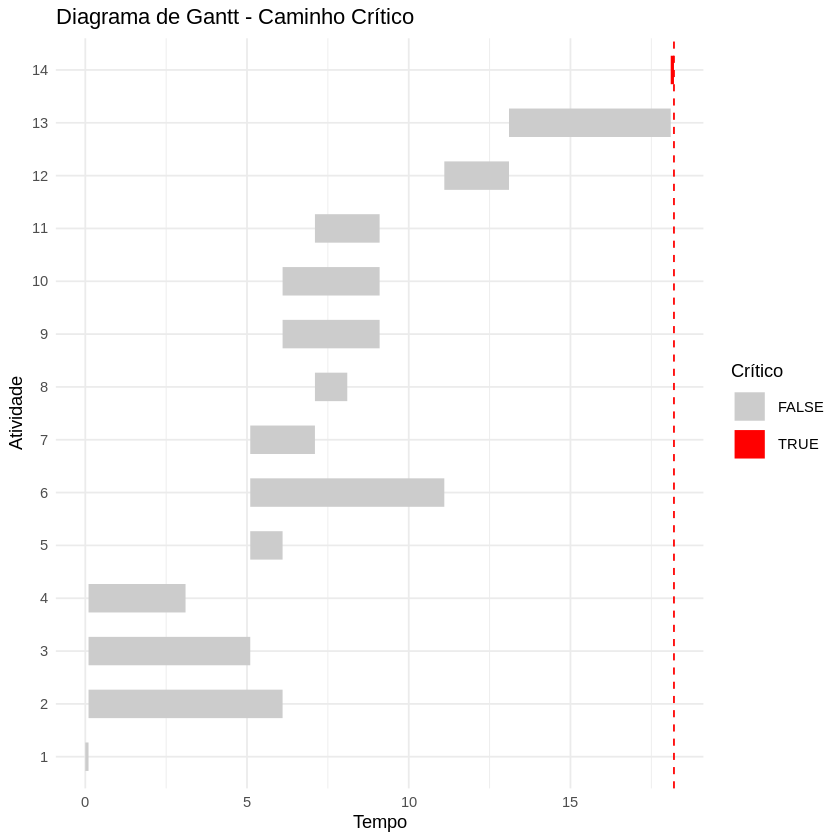

In [10]:
cronograma <- data.frame(
  atividade = 1:n,
  inicio    = r$est,
  duracao   = d
)

cronograma$fim <- cronograma$inicio + cronograma$duracao

# caminho crítico (slack = 0)
cronograma$critico <- r$slack == 0
library(ggplot2)

ggplot(cronograma,
       aes(x = inicio,
           xend = fim,
           y = factor(atividade),
           yend = factor(atividade))) +

  geom_segment(aes(color = critico),
               linewidth = 8) +

  geom_vline(xintercept = r$duracao,
             linetype = "dashed",
             color = "red") +

  scale_color_manual(values = c(
    "TRUE"  = "red",      # caminho crítico
    "FALSE" = "grey80"    # demais atividades
  )) +

  scale_x_continuous(limits = c(0, r$duracao)) +

  labs(title = "Diagrama de Gantt - Caminho Crítico",
       x = "Tempo",
       y = "Atividade",
       color = "Crítico") +

  theme_minimal()

## Comparação


In [11]:
suppressMessages(library(igraph))
library(ggplot2)
set.seed(42)

# ============================================================
# ESTRUTURAS DE DADOS
# ============================================================
n  <- 14
Ns <- 10000

parDur <- matrix(data = c(
  0,   0.1, 0.2,
  4,   6,   10,
  2,   5,   8,
  2,   3,   6,
  0.5, 1,   2,
  3,   6,   10,
  1,   2,   4,
  0.5, 1,   3,
  2,   3,   6,
  2,   3,   5,
  1,   2,   3,
  1,   2,   4,
  3,   5,   8,
  0,   0.1, 0.2
), ncol = 3, byrow = TRUE)
# colunas: [Min, Mprov (moda), Max]

elos <- c(1,2, 1,3, 1,4, 2,9, 3,5, 3,6, 3,7,
          4,8, 5,10, 6,12, 7,11, 7,8, 8,13,
          9,14, 10,12, 11,12, 12,13, 13,14)

Suc <- list(c(2,3,4), 9, c(5,6,7), 8, 10, 12,
            c(8,11), 13, 14, 12, 12, 13, 14, 0)

Pre <- list(0, 1, 1, 1, 3, 3, 3, c(4,7), 2, 5,
            7, c(6,10,11), c(8,12), c(9,13))

In [12]:
rtri <- function(n, a, c, b) {
  # a=min, b=max, c=modo
  if (b == a) return(rep(a, n))
  u  <- runif(n)
  fc <- (c - a) / (b - a)
  ifelse(u < fc,
    a + sqrt(u  * (b - a) * (c - a)),
    b - sqrt((1 - u) * (b - a) * (b - c))
  )
}

In [13]:
g  <- make_graph(elos)
sp <- all_simple_paths(g, from = 1, to = 14)
l  <- length(sp)
cat(sprintf("Caminhos encontrados: %d\n", l))
for (k in seq_len(l))
  cat(sprintf("  Caminho %d: %s\n", k,
              paste(as.integer(sp[[k]]), collapse = " -> ")))

Caminhos encontrados: 6
  Caminho 1: 1 -> 2 -> 9 -> 14
  Caminho 2: 1 -> 3 -> 5 -> 10 -> 12 -> 13 -> 14
  Caminho 3: 1 -> 3 -> 6 -> 12 -> 13 -> 14
  Caminho 4: 1 -> 3 -> 7 -> 8 -> 13 -> 14
  Caminho 5: 1 -> 3 -> 7 -> 11 -> 12 -> 13 -> 14
  Caminho 6: 1 -> 4 -> 8 -> 13 -> 14


In [14]:
funcCpm <- function(n, d, Suc, Pre) {
  est <- eft <- lst <- lft <- numeric(n)

  # Forward pass
  cpmf <- function(s, est) {
    eft[s] <<- est[s] + d[s]
    if (Suc[[s]][1] != 0)
      for (i in Suc[[s]]) {
        if (est[i] < eft[s]) est[i] <- eft[s]
        est <- cpmf(i, est)
      }
    est
  }

  # Backward pass
  cpmb <- function(s, lft) {
    lst[s] <<- lft[s] - d[s]
    if (Pre[[s]][1] != 0)
      for (i in Pre[[s]]) {
        if (lft[i] > lst[s]) lft[i] <- lst[s]
        lft <- cpmb(i, lft)
      }
    lft
  }

  rf  <- cpmf(1, est)
  lf  <- rep(rf[n] + d[n], n)
  rb  <- cpmb(n, lf) - d
  list(est = rf, lst = rb, slack = rb - rf)
}


In [15]:
dur <- matrix(0, nrow = Ns, ncol = n)
for (i in 2:(n - 1))                       # ativ 1 e 14 = duracao 0
  dur[, i] <- ceiling(rtri(Ns,
                            parDur[i, 1],
                            parDur[i, 2],
                            parDur[i, 3]))


In [16]:
path_dur <- matrix(0, nrow = Ns, ncol = l)
for (j in seq_len(l))
  path_dur[, j] <- rowSums(dur[, as.integer(sp[[j]]), drop = FALSE])


In [17]:
# Duração total do projeto e índice do caminho crítico
durCC  <- apply(path_dur, 1, max)
icc    <- apply(path_dur, 1, which.max)   # caminho crítico de cada cenário


In [18]:
# ITEM 1 – Duração total do projeto
cat(sprintf("  Média   : %.2f\n",  mean(durCC)))
cat(sprintf("  Mediana : %.2f\n",  median(durCC)))
cat(sprintf("  Desvio  : %.2f\n",  sd(durCC)))
cat(sprintf("  Min/Max : %d / %d\n", min(durCC), max(durCC)))
cat(sprintf("  P85     : %.1f\n",  quantile(durCC, 0.85)))

  Média   : 21.27
  Mediana : 21.00
  Desvio  : 2.17
  Min/Max : 15 / 29
  P85     : 24.0


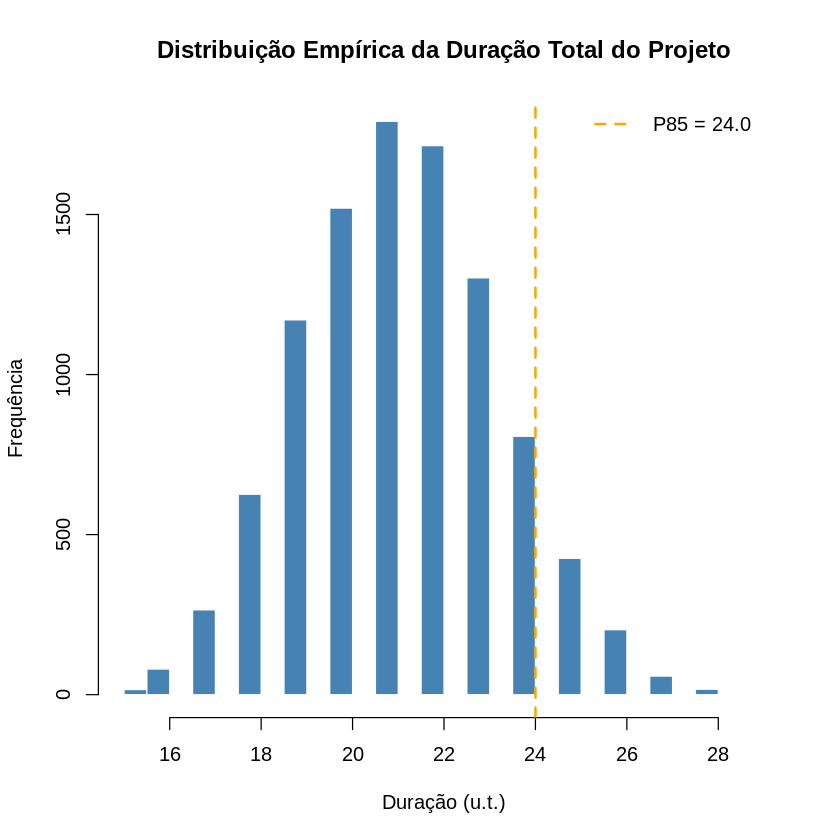

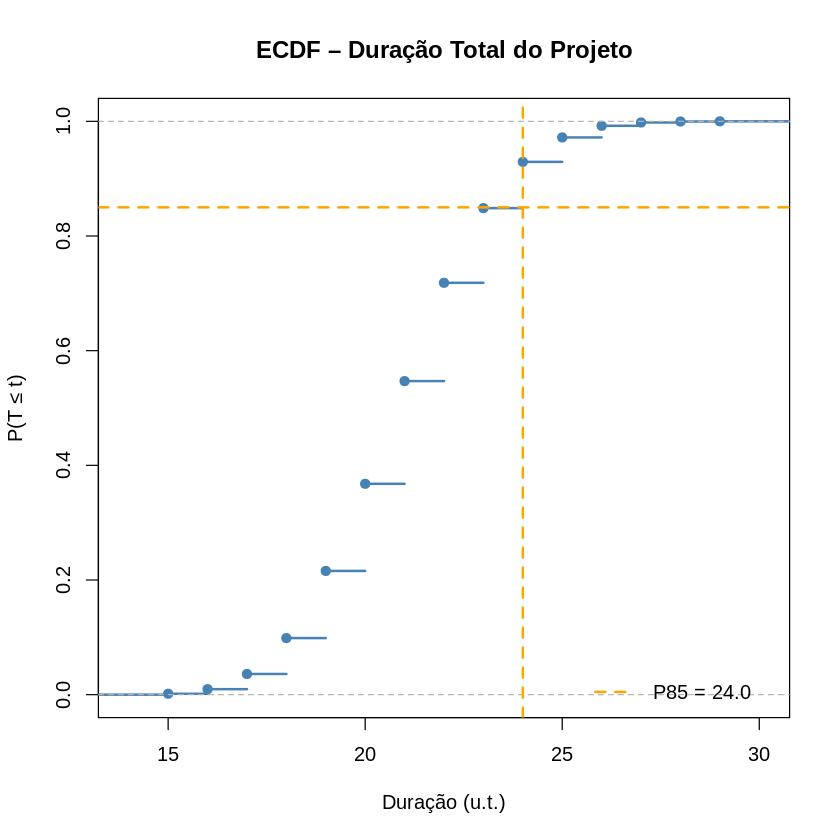

In [19]:
# =========================
# HISTOGRAMA
# =========================

hist(
  durCC,
  breaks = 30,
  col = "steelblue",
  border = "white",
  main = "Distribuição Empírica da Duração Total do Projeto",
  xlab = "Duração (u.t.)",
  ylab = "Frequência"
)

# Linha do percentil 85
abline(
  v = quantile(durCC, 0.85),
  col = "orange",
  lwd = 2,
  lty = 2
)

legend(
  "topright",
  legend = sprintf("P85 = %.1f", quantile(durCC, 0.85)),
  col = "orange",
  lwd = 2,
  lty = 2,
  bty = "n"
)

# =========================
# ECDF
# =========================

plot(
  ecdf(durCC),
  main = "ECDF – Duração Total do Projeto",
  xlab = "Duração (u.t.)",
  ylab = "P(T ≤ t)",
  col = "steelblue",
  lwd = 2
)

abline(
  h = 0.85,
  col = "orange",
  lwd = 2,
  lty = 2
)

abline(
  v = quantile(durCC, 0.85),
  col = "orange",
  lwd = 2,
  lty = 2
)

legend(
  "bottomright",
  legend = sprintf("P85 = %.1f", quantile(durCC, 0.85)),
  col = "orange",
  lwd = 2,
  lty = 2,
  bty = "n"
)


========== ITEM 2: P(atividade no caminho crítico) ==========
  Atividade  1: 100.0%
  Atividade  2: 0.0%
  Atividade  3: 100.0%
  Atividade  4: 0.0%
  Atividade  5: 27.2%
  Atividade  6: 66.0%
  Atividade  7: 6.8%
  Atividade  8: 0.0%
  Atividade  9: 0.0%
  Atividade 10: 27.2%
  Atividade 11: 6.8%
  Atividade 12: 100.0%
  Atividade 13: 100.0%
  Atividade 14: 100.0%


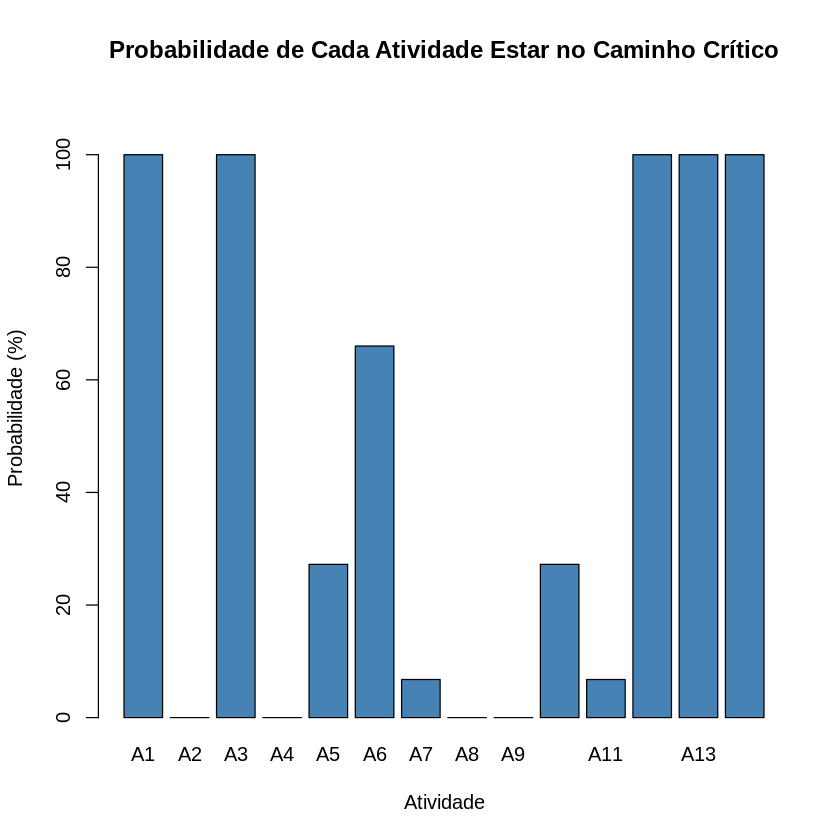

In [20]:
cat("\n========== ITEM 2: P(atividade no caminho crítico) ==========\n")

contCC <- rep(0, n)

for (i in seq_len(Ns)) {
  contCC[as.integer(sp[[icc[i]]])] <-
    contCC[as.integer(sp[[icc[i]]])] + 1
}

probCC <- contCC / Ns

for (i in seq_len(n)) {
  cat(sprintf("  Atividade %2d: %.1f%%\n", i, probCC[i] * 100))
}

# =========================
# GRÁFICO DE BARRAS
# =========================

barplot(
  probCC * 100,
  names.arg = paste0("A", 1:n),
  col = ifelse(probCC > 0, "steelblue", "gray85"),
  main = "Probabilidade de Cada Atividade Estar no Caminho Crítico",
  xlab = "Atividade",
  ylab = "Probabilidade (%)",
  ylim = c(0, 110)
)


========== ITEM 3: Distribuição dos inícios mais cedo ==========
  Atividade | Média  | P50   | P85
  ----------|--------|-------|------
  Ativ  1   |  0.00  |   0.0 |   0.0
  Ativ  2   |  0.00  |   0.0 |   0.0
  Ativ  3   |  0.00  |   0.0 |   0.0
  Ativ  4   |  0.00  |   0.0 |   0.0
  Ativ  5   |  5.48  |   5.5 |   7.0
  Ativ  6   |  5.48  |   5.5 |   7.0
  Ativ  7   |  5.48  |   5.5 |   7.0
  Ativ  8   |  8.33  |   8.0 |  10.0
  Ativ  9   |  7.16  |   7.0 |   9.0
  Ativ 10   |  7.15  |   7.0 |   9.0
  Ativ 11   |  8.33  |   8.0 |  10.0
  Ativ 12   | 12.60  |  13.0 |  14.0
  Ativ 13   | 15.43  |  15.0 |  17.0
  Ativ 14   | 21.27  |  21.0 |  24.0


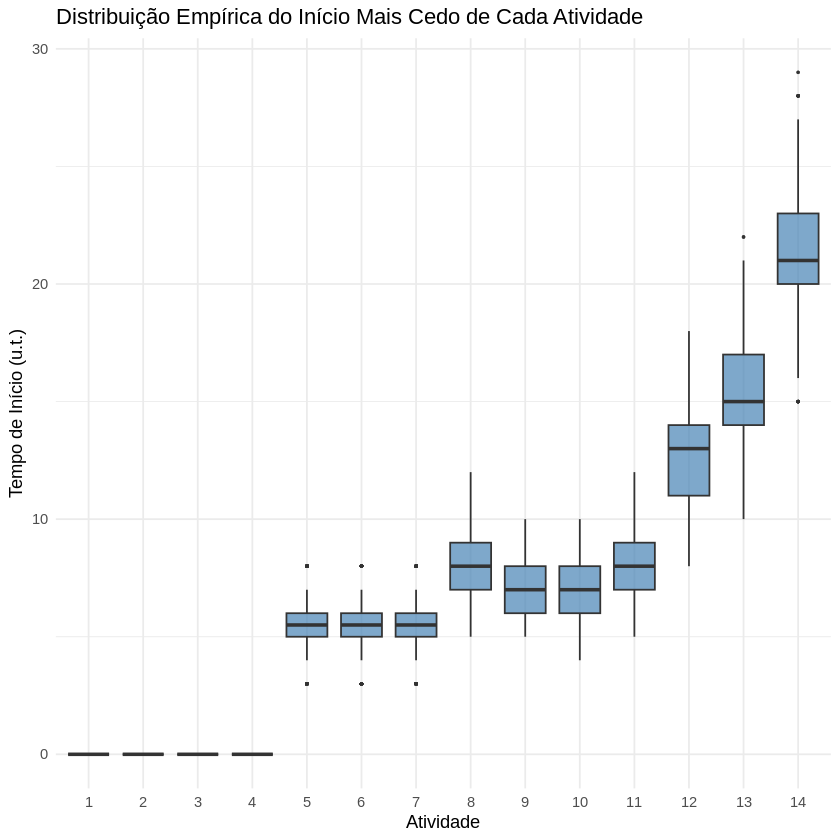

In [21]:
# ============================================================
# ITEM 3 – Distribuição dos inícios mais cedo
# ============================================================

cat("\n========== ITEM 3: Distribuição dos inícios mais cedo ==========\n")

# Carregar pacote
library(ggplot2)

est_mc <- matrix(0, nrow = Ns, ncol = n)

for (i in seq_len(Ns)) {
  r_i <- funcCpm(n, dur[i, ], Suc, Pre)
  est_mc[i, ] <- r_i$est
}

cat("  Atividade | Média  | P50   | P85\n")
cat("  ----------|--------|-------|------\n")

for (i in seq_len(n)) {
  cat(sprintf(
    "  Ativ %2d   | %5.2f  | %5.1f | %5.1f\n",
    i,
    mean(est_mc[, i]),
    quantile(est_mc[, i], 0.50),
    quantile(est_mc[, i], 0.85)
  ))
}

# =========================
# BOXPLOT DOS INÍCIOS
# =========================

df_est <- data.frame(
  inicio = as.vector(est_mc),
  atividade = factor(rep(1:n, each = Ns))
)

p3 <- ggplot(df_est, aes(x = atividade, y = inicio)) +
  geom_boxplot(
    fill = "steelblue",
    alpha = 0.7,
    outlier.size = 0.3
  ) +
  labs(
    title = "Distribuição Empírica do Início Mais Cedo de Cada Atividade",
    x = "Atividade",
    y = "Tempo de Início (u.t.)"
  ) +
  theme_minimal()

print(p3)


In [22]:
# ============================================================
# ITEM 4 – Cronograma com 85% de chance de ser cumprido
# ============================================================

cat("\n========== ITEM 4: Cronograma com 85% de chance ==========\n")

# P85 da duração total
prazo85 <- as.numeric(quantile(durCC, 0.85))

# P85 dos inícios e durações
si85 <- apply(
  est_mc,
  2,
  function(x) as.numeric(quantile(x, 0.85))
)

di85 <- apply(
  dur,
  2,
  function(x) as.numeric(quantile(x, 0.85))
)

# Cronograma
cron <- data.frame(
  Atividade = 1:n,
  Inicio = round(si85, 1),
  Duracao = round(di85, 1),
  Fim = round(si85 + di85, 1)
)

cat(sprintf(
  "  Prazo do projeto com 85%% de chance: %.1f u.t.\n\n",
  prazo85
))

print(cron)


========== ITEM 4: Cronograma com 85% de chance ==========
  Prazo do projeto com 85% de chance: 24.0 u.t.

   Atividade Inicio Duracao Fim
1          1      0       0   0
2          2      0       9   9
3          3      0       7   7
4          4      0       5   5
5          5      7       2   9
6          6      7       8  15
7          7      7       4  11
8          8     10       3  13
9          9      9       5  14
10        10      9       5  14
11        11     10       3  13
12        12     14       4  18
13        13     17       7  24
14        14     24       0  24



========== ITEM 5: Diagrama de Gantt ==========
  Gantt gerado.

=== Concluído! ===


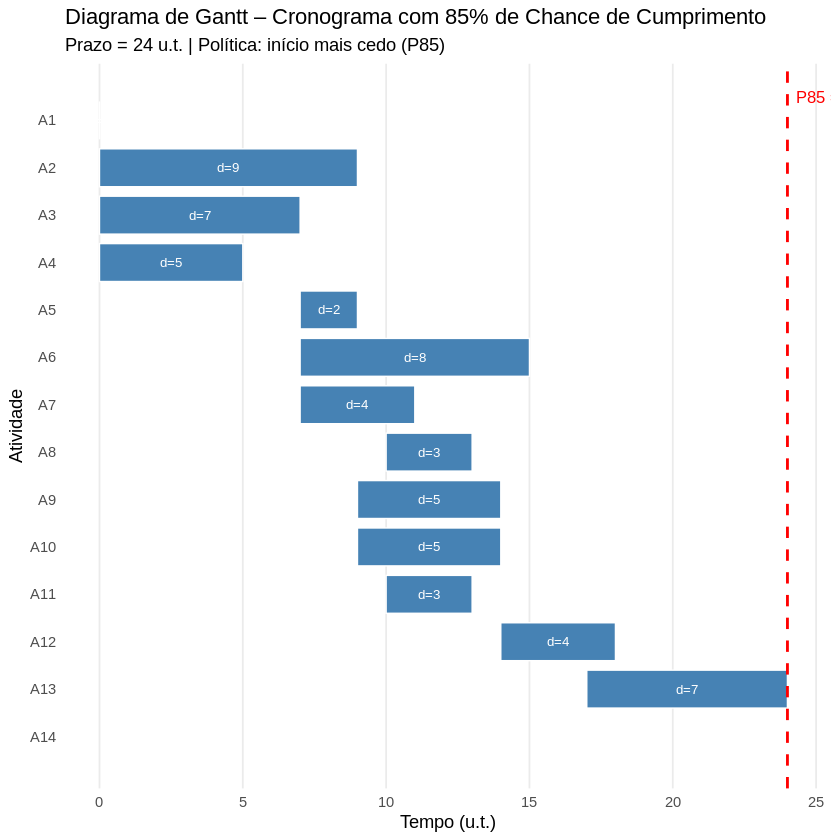

In [23]:
# ============================================================
# ITEM 5 – Diagrama de Gantt
# ============================================================

cat("\n========== ITEM 5: Diagrama de Gantt ==========\n")

cron$Atividade_f <- factor(
  paste0("A", cron$Atividade),
  levels = rev(paste0("A", 1:n))
)

gantt <- ggplot(
  cron,
  aes(
    xmin = Inicio,
    xmax = Fim,
    ymin = as.numeric(Atividade_f) - 0.4,
    ymax = as.numeric(Atividade_f) + 0.4
  )
) +
  geom_rect(
    fill = "steelblue",
    colour = "white",
    linewidth = 0.4
  ) +
  geom_text(
    aes(
      x = (Inicio + Fim) / 2,
      y = as.numeric(Atividade_f),
      label = sprintf("d=%.0f", Duracao)
    ),
    size = 2.8,
    colour = "white"
  ) +
  geom_vline(
    xintercept = prazo85,
    colour = "red",
    linetype = "dashed",
    linewidth = 0.8
  ) +
  annotate(
    "text",
    x = prazo85 + 0.3,
    y = n + 0.5,
    label = sprintf("P85 = %.0f", prazo85),
    colour = "red",
    size = 3.5,
    hjust = 0
  ) +
  scale_y_continuous(
    breaks = seq_len(n),
    labels = rev(paste0("A", 1:n))
  ) +
  labs(
    title = "Diagrama de Gantt – Cronograma com 85% de Chance de Cumprimento",
    subtitle = sprintf(
      "Prazo = %.0f u.t. | Política: início mais cedo (P85)",
      prazo85
    ),
    x = "Tempo (u.t.)",
    y = "Atividade"
  ) +
  theme_minimal(base_size = 11) +
  theme(
    panel.grid.minor = element_blank(),
    panel.grid.major.y = element_blank()
  )

print(gantt)

cat("  Gantt gerado.\n")
cat("\n=== Concluído! ===\n")